# Fyxer AI — ML Engineering Take-Home

**Time expectation:** 3 hours

**Submission format:** Complete this notebook with your code, outputs, and written commentary. Return the finished `.ipynb` file.

**What we're looking for:** Quality of thinking over quantity of code. We care about how you frame problems, justify decisions, and communicate results — not just whether the model runs.

## Business Context

Fyxer AI helps professionals manage their inboxes. One core feature is labelling emails that need a reply — we call these **"to-respond"** emails.

Today, this is powered by a **fine-tuned LLM**. It works, but we want to explore whether a traditional ML approach could outperform it while being faster at inference, lower in cost, and more predictable to maintain.

Your task is to **validate whether a traditional ML model can beat the current system** at predicting which emails a user will reply to.

The dataset contains a synthetic dataset of emails along with the current system's predictions.

## Dataset

- **1,702,298 emails** from **200 users** over ~5 months (Oct 2025 – Feb 2026)
- Each row is one email received by a user
- **48 columns** across identifiers, sender history, user behaviour, thread context, timing, email content, and rule-based flags

---

### Identifiers & Target

| Column | Type | Description |
|--------|------|-------------|
| `email_message_id` | string | Unique identifier for each email message |
| `user_id` | string | Unique identifier for the recipient user |
| `created_at` | timestamp | Timestamp when the email was received (UTC) |
| `target_replied` | boolean | **Target variable** — whether the user replied to this email |
| `current_system_predicted_reply` | boolean | Whether the current system predicted a reply for this email |

### Sender Features

| Column | Type | Description |
|--------|------|-------------|
| `emails_from_sender_alltime` | int | Total emails received from this sender before this email |
| `emails_from_sender_30d` | int | Emails received from this sender in the 30 days before this email |
| `days_since_last_email_from_sender` | float | Days since the previous email from this sender (null if first) |
| `reply_rate_sender_alltime` | float | User's historical reply rate to this sender (all time, before this email) |
| `reply_rate_sender_30d` | float | User's reply rate to this sender in the prior 30 days |
| `sender_reply_latency_avg_hours` | float | Average hours the user takes to reply to this sender |
| `read_rate_sender_alltime` | float | Proportion of emails from this sender the user has read |
| `user_has_emailed_sender_before` | boolean | Whether the user has previously sent an email to this sender |
| `sender_is_personal_email` | boolean | Whether the sender's email is a personal domain (e.g. gmail, yahoo) |

### User Features

| Column | Type | Description |
|--------|------|-------------|
| `user_overall_reply_rate_alltime` | float | User's overall reply rate across all senders (before this email) |
| `user_overall_reply_rate_30d` | float | User's overall reply rate in the prior 30 days |
| `user_email_volume_received_30d` | int | Total emails the user received in the prior 30 days |
| `user_email_volume_sent_30d` | int | Total emails the user sent in the prior 30 days |
| `user_draft_adoption_rate` | float | Proportion of AI-generated drafts the user has accepted |
| `user_is_active` | boolean | Whether the user is currently an active product user |
| `user_tenure_days` | int | Days since the user created their account (clipped to [0, 1825]) |
| `user_is_personal_email` | int | Whether the user's own email is a personal domain |
| `is_paid_user` | boolean | Whether the user is on a paid plan |

### Thread Features

| Column | Type | Description |
|--------|------|-------------|
| `position_in_thread` | int | This email's position in the thread (1 = thread starter) |
| `thread_length_so_far` | int | Number of messages in the thread up to and including this one |
| `thread_age_hours` | int | Hours since the first message in the thread (clipped to 8,760) |
| `hours_since_last_message` | float | Hours since the previous message in the thread (clipped to 8,760; null if first) |
| `user_reply_count_in_thread_before` | int | Number of times the user has already replied in this thread |
| `thread_participant_count` | int | Number of distinct participants in the thread so far |

### Temporal Features

| Column | Type | Description |
|--------|------|-------------|
| `is_weekend` | boolean | Whether the email arrived on a Saturday or Sunday |
| `is_business_hours` | boolean | Whether the email arrived during business hours (9am–6pm user local time) |

### Email Features

| Column | Type | Description |
|--------|------|-------------|
| `to_recipient_count` | int | Number of recipients in the To field |
| `is_same_domain_as_user` | boolean | Whether the sender's domain matches the user's domain |
| `sender_is_noreply` | boolean | Whether the sender is a noreply/no-reply address |
| `attachment_count` | int | Number of attachments on the email |
| `subject_length` | int | Character length of the email subject line |
| `subject_prefix` | string | Extracted prefix from the subject (e.g. "Re:", "Fwd:") |

### Rule-Based Flags

| Column | Type | Description |
|--------|------|-------------|
| `is_automated` | boolean | Email detected as automated/machine-generated |
| `is_internal` | boolean | Sender is within the same organisation as the user |
| `is_mass_email` | boolean | Email detected as a mass/bulk send |
| `is_forwarded` | boolean | Email is a forward |
| `has_no_content` | boolean | Email body is empty or has no meaningful content |
| `is_spam` | boolean | Email detected as spam |
| `is_invite` | boolean | Email is a calendar invitation |
| `is_invite_response` | boolean | Email is a response to a calendar invitation |
| `is_calendar_reply` | boolean | Email is an automated calendar reply |
| `is_matched_email_address` | boolean | Sender matches a user-configured email address rule |
| `is_out_of_office` | boolean | Email is an out-of-office auto-reply |

---

**Notes:**
- All features with time windows (alltime, 30d) are computed using only data **before** the current email — no data leakage
- Null values in sender features indicate the first email ever received from that sender
- `hours_since_last_message` is null for thread starters (`position_in_thread` = 1)
- `current_system_predicted_reply` is included as a baseline — the current system's prediction

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv") ## Note this is a large file, so it may take 30 seconds or longer to load.
df.shape

(1702298, 48)

In [3]:
df.head()

,email_message_id,user_id,created_at,target_replied,current_system_predicted_reply,emails_from_sender_alltime,emails_from_sender_30d,days_since_last_email_from_sender,reply_rate_sender_alltime,reply_rate_sender_30d,...,is_internal,is_mass_email,is_forwarded,has_no_content,is_spam,is_invite,is_invite_response,is_calendar_reply,is_matched_email_address,is_out_of_office
0,2c4c0079d3706a6a,8d70c677d14d1f0d,2026-02-23 15:50:34.304 UTC,False,False,15,6,1.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,c533b2351640f808,8d70c677d14d1f0d,2026-02-21 15:50:30.437 UTC,False,False,13,4,1.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,01711fabbc119f2a,8d70c677d14d1f0d,2026-02-22 15:50:31.696 UTC,False,False,14,5,1.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,e5d53b82e67727e6,8d70c677d14d1f0d,2026-01-01 18:29:59.744 UTC,False,False,2,0,30.0,0.0,NaN,...,False,True,False,False,False,False,False,False,False,False
4,32fed07f0d147af0,8d70c677d14d1f0d,2026-01-06 17:35:14.798 UTC,False,False,5,0,35.0,0.0,NaN,...,False,False,False,False,False,False,False,False,False,False


---

## Section 1 — Problem Understanding

Before writing any model code, take a moment to frame the problem.

- How would you define success for this model?
- What evaluation metric(s) will you use, and why?
- Are there any risks or subtleties you'd want to keep in mind?

#### Success can be defined as

> The traditional ML model outperforms the current fine-tuned LLM on the primary evaluation metric(s) by a meaningful margin (e.g., ≥5% relative improvement), while also meeting operational goals (faster inference, lower cost, easier maintenance).
>
> Given cold start constraints, success may be segment-specific: we use traditional ML where we have sufficient sender and user history (rich, non-null features), and rely on the fine-tuned LLM for cold start cases (new users and new senders). As we gather more data, we gradually move those cases into the traditional ML model, with clear triggers (e.g., N emails from a sender, M days of user activity) governing when to switch.

#### Evaluation metrics

This is traditional binary classification. Primary offline metrics: Precision, Recall, F1, and AUC-ROC.

**AUC-ROC:** Threshold-independent; useful for comparing models.

**Precision / Recall / F1:** Threshold-dependent; we choose a threshold based on business priorities.

**Threshold tuning:** We convert predicted probabilities to binary labels via a tunable threshold. We expect recall to be more important than precision: missing a reply-worthy email is worse than occasionally flagging one that doesn’t need a reply. Still, if recall is pushed too high, users may see many low-value suggestions and disengage (alert fatigue), so we’ll monitor both metrics together.

**Baseline comparison:** We compute these metrics for `current_system_predicted_reply` and report relative improvements (e.g., +X% recall, ±Y% precision vs current system).

**Evaluation setup:** We use stratified (e.g., per-user) aggregation to avoid high-volume users dominating results, and evaluate on a temporal holdout (e.g., last month) to reflect production performance.

#### Potential Risks

**Baseline fairness:** The LLM may already perform well because they use subject and email body text. The bar for “success” should be clear: at least one strong improvement (e.g., recall or precision) while preserving or improving the other and operational constraints.

**Distribution shift:** Inbox behavior and email volume can change over time (seasonality, product changes, new user segments). We should monitor feature drift and label rates, and plan for periodic retraining and evaluation.

**Lack of text features:** The traditional model cannot use semantic content (e.g., “Urgent”, “Can you send the report by Friday?”). Features like subject_length, subject_prefix, and rule-based flags capture only part of this signal. This is the core limitation we are validating; if performance is close despite it, the traditional model may still be attractive for operational reasons.

**Data leakage:** If train/validation/test splits are not done by user and time, we may overestimate performance. Splits must respect user boundaries and temporal order.

**Cold start:** New users and new senders have sparse or null behavioral features. The traditional model may perform poorly on these segments; a hybrid approach with the LLM for cold start is worth considering.


> **Assumption:** We assume the target labels are correct, but in practice they may be slightly biased or noisy. For example, labels may include accidental replies (e.g., mis-clicks or automated responses) and may miss replies made outside the tracked system or after the labeling window. If such noise is present, it can modestly affect measured precision and recall, though the relative comparison between models (e.g., LGBM vs. LLM) is typically more robust.

---

## Section 2 — Data Exploration & Validation

Understand what you're working with before modelling.

- What is the class balance? How much data is there per user?
- What types of features are present — their distributions, missingness, anything unusual?


In [7]:
df["target_replied"].value_counts(normalize=True)

target_replied
False    0.983825
True     0.016175
Name: proportion, dtype: float64

In [8]:
df["current_system_predicted_reply"].value_counts(normalize=True)

current_system_predicted_reply
False    0.974308
True     0.025692
Name: proportion, dtype: float64

In [10]:
# Current LLM system metrics:
from sklearn.metrics import precision_score, recall_score, f1_score

true = df["target_replied"]
predictions = df["current_system_predicted_reply"]
precision = precision_score(true, predictions)
recall = recall_score(true, predictions)
f1 = f1_score(true, predictions)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Precision: 0.3735
Recall:    0.5932
F1 Score:  0.4584


<Axes: >

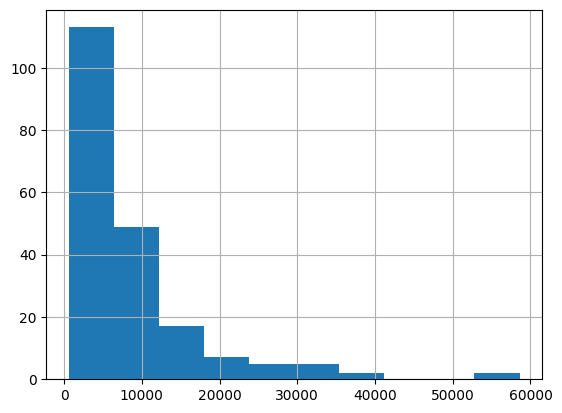

In [20]:
df["user_id"].value_counts().hist()

> Email volume per user is heavily skewed: most users (~150) have &lt;10k emails, while ~50 users have &gt;10k. **Stratified evaluation is recommended** so results are not dominated by high-volume users.

#### Key Feature Distributions

Analyzing distributions for a subset of important features that are likely predictive of reply behavior: sender engagement, user behavior, thread context, temporal signals, and rule-based flags.

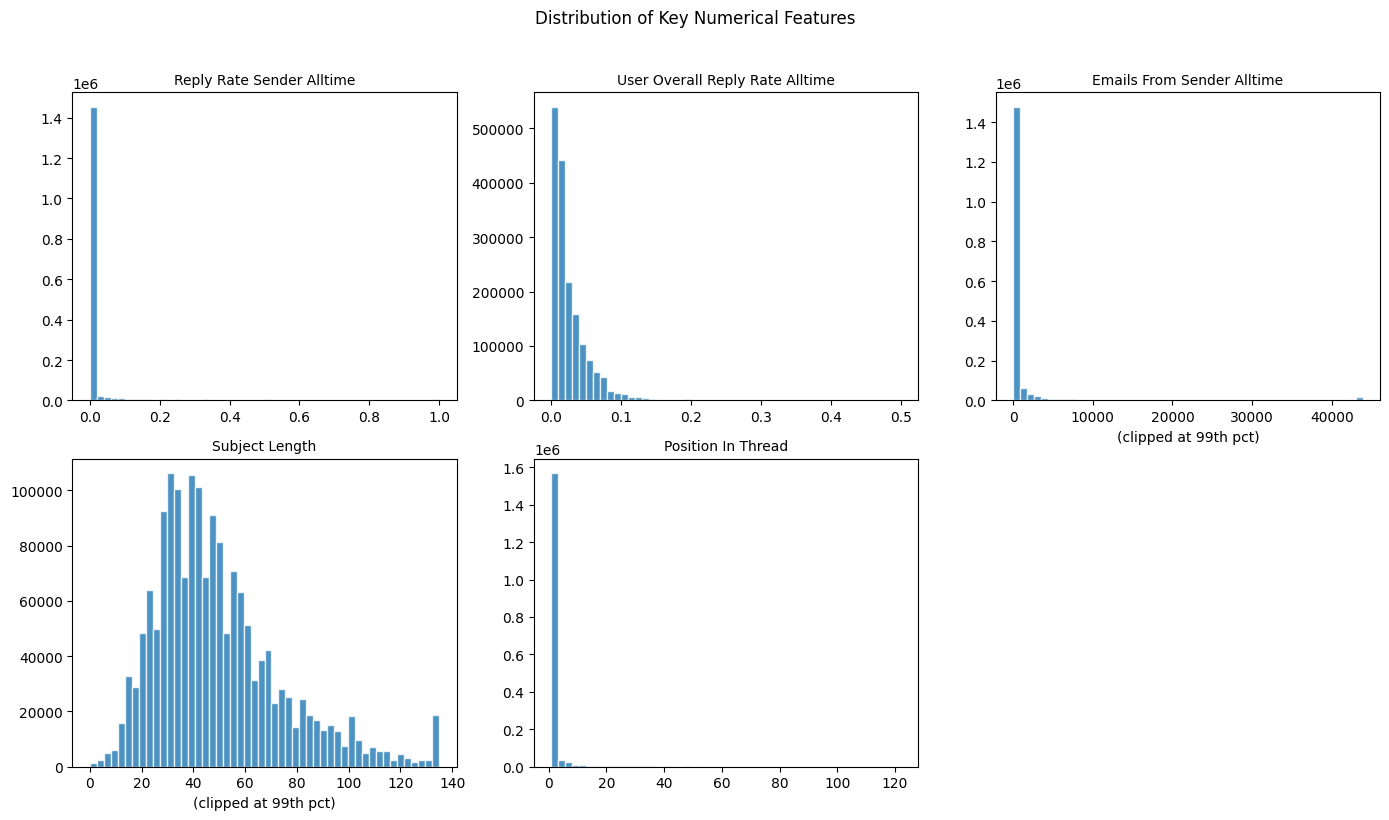

In [33]:
# Numerical features: distributions and summary stats
import matplotlib.pyplot as plt

num_features = [
    "reply_rate_sender_alltime",
    "user_overall_reply_rate_alltime",
    "emails_from_sender_alltime",     
    "subject_length",                 
    "position_in_thread",             
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    ax = axes[i]
    data = df[col].dropna()
    # Clip extreme outliers for visualization (e.g., subject_length, emails_from_sender)
    if col in ["emails_from_sender_alltime", "subject_length"]:
        data = data.clip(upper=data.quantile(0.99))
    ax.hist(data, bins=50, edgecolor="white", alpha=0.8)
    ax.set_title(col.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel("")
    if col in ["emails_from_sender_alltime", "subject_length"]:
        ax.set_xlabel("(clipped at 99th pct)")

axes[-1].axis("off")

plt.suptitle("Distribution of Key Numerical Features", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
stats = df[num_features].describe().round(4)
stats

,reply_rate_sender_alltime,user_overall_reply_rate_alltime,emails_from_sender_alltime,subject_length,position_in_thread
count,1.607376e+06,1.702260e+06,1.702298e+06,1.702298e+06,1.702298e+06
mean,2.080000e-02,2.580000e-02,1.517218e+03,5.033190e+01,2.549300e+00
std,9.510000e-02,2.790000e-02,6.543639e+03,6.498340e+01,8.024500e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,0.000000e+00,8.500000e-03,1.200000e+01,3.200000e+01,1.000000e+00
50%,0.000000e+00,1.520000e-02,5.900000e+01,4.400000e+01,1.000000e+00
75%,0.000000e+00,3.400000e-02,2.680000e+02,6.100000e+01,1.000000e+00
max,1.000000e+00,5.000000e-01,6.087700e+04,1.000000e+04,1.220000e+02


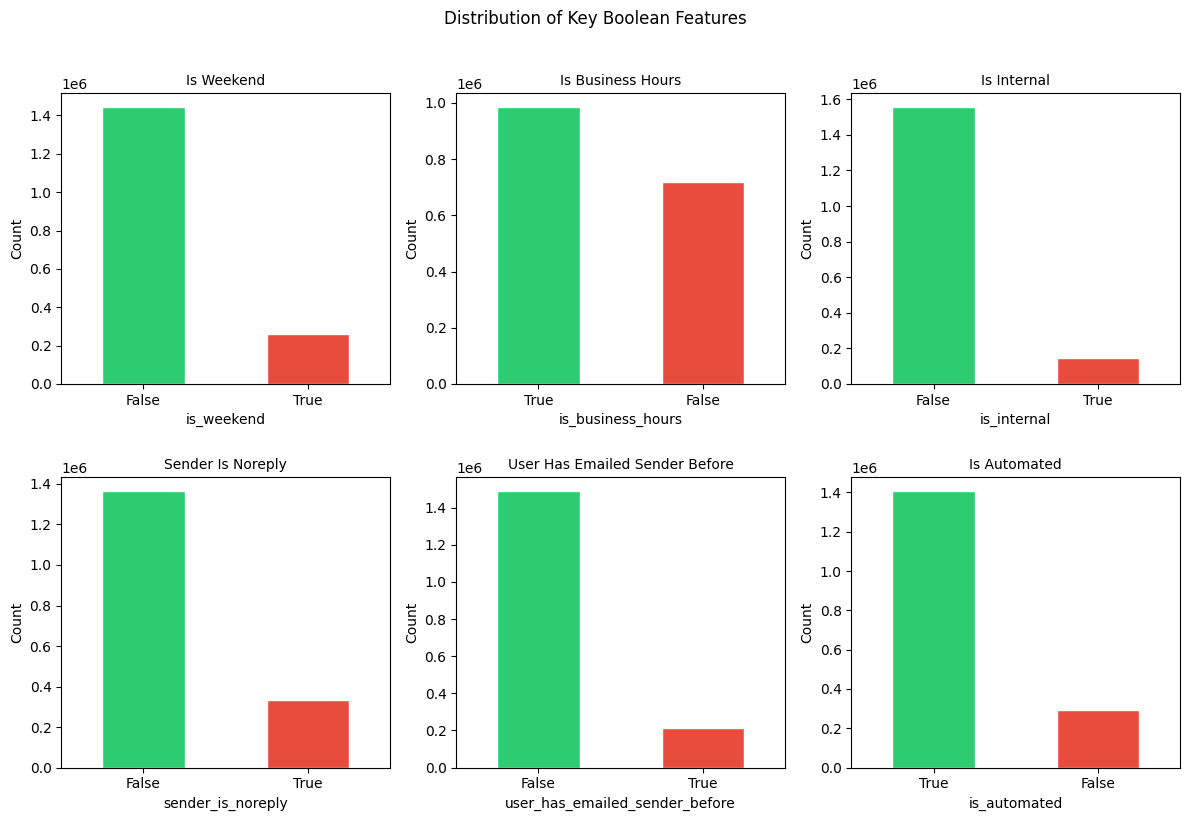

In [34]:
# Categorical / boolean features
bool_features = [
    "is_weekend",
    "is_business_hours",
    "is_internal",
    "sender_is_noreply",
    "user_has_emailed_sender_before",
    "is_automated",
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(bool_features):
    ax = axes[i]
    counts = df[col].value_counts()
    counts.plot(kind="bar", ax=ax, color=["#2ecc71", "#e74c3c"], edgecolor="white")
    ax.set_title(col.replace("_", " ").title(), fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_ylabel("Count")

plt.suptitle("Distribution of Key Boolean Features", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [51]:
df[df["is_automated"] == 0]["target_replied"].value_counts(normalize=True)

target_replied
False    0.916898
True     0.083102
Name: proportion, dtype: float64

In [52]:
df[df["is_automated"] == 1]["target_replied"].value_counts(normalize=True)

target_replied
False    0.997795
True     0.002205
Name: proportion, dtype: float64

`is_automated` is an important feature, the chances of the user replying to an email increases by 37% if the email is not automated.

subject_prefix - Top values:
subject_prefix
none    1547795
Re       137940
Fwd       16563
Name: count, dtype: int64


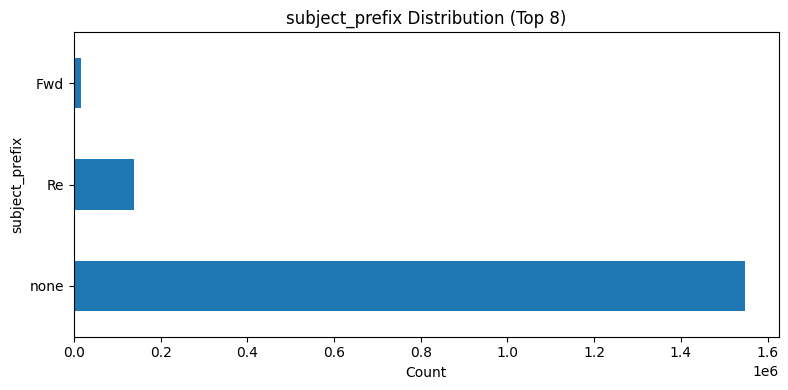

In [35]:
# subject_prefix (string categorical)
print("subject_prefix - Top values:")
print(df["subject_prefix"].value_counts(dropna=False).head(10))
df["subject_prefix"].value_counts().head(8).plot(kind="barh", figsize=(8, 4))
plt.title("subject_prefix Distribution (Top 8)")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

In [58]:
df["subject_prefix"].value_counts(normalize=True)

subject_prefix
2    0.909239
1    0.081032
0    0.009730
Name: proportion, dtype: float64

In [36]:
# Missingness for key features (null = cold start / first contact)
cols_to_check = [
    "reply_rate_sender_alltime",
    "reply_rate_sender_30d",
    "days_since_last_email_from_sender",
    "hours_since_last_message",
]

missing = df[cols_to_check].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print("Missingness in sender/thread features (cold start indicators):")
print(missing_df)

Missingness in sender/thread features (cold start indicators):
                                   Missing Count  Missing %
reply_rate_sender_alltime                  94922       5.58
reply_rate_sender_30d                     149917       8.81
days_since_last_email_from_sender          94922       5.58
hours_since_last_message                 1446639      84.98


#### Data Exploration Summary

**Class balance & baseline performance**

- **Target:** ~98.4% no reply, ~1.6% reply (strong class imbalance).
- **Current LLM:** Predicts reply for ~2.6% of emails.
- **Current LLM metrics:** Precision 0.37, Recall 0.59, F1 0.46.

**User distribution**

- Email volume per user is skewed: most users have <10k emails, while ~50 users have >10k.
- Stratified or per-user evaluation is recommended so high-volume users do not dominate metrics.

**Feature distributions**

- **`reply_rate_sender_alltime`:** Mean 2.1%, many zeros; ~5.5% nulls (first contact with sender). Strong candidate for reply prediction.
- **`user_overall_reply_rate_alltime`:** Mean ~2.6%; baseline user reply tendency.
- **`emails_from_sender_alltime`:** Highly skewed (mean ~1,500, std ~6,500); most senders have few prior emails.
- **`subject_length`:** Mean ~50 characters.
- **`position_in_thread`:** Mean ~2.5 (mix of starters and follow-ups).

**`is_automated`**

- **Automated emails (True):** Reply rate ~0.2%.
- **Non-automated emails (False):** Reply rate ~8.3%.
- Reply rate is ~37× higher for non-automated emails, so `is_automated` is a strong filter feature.

**Missingness & cold start**

- Sender features (`reply_rate_sender_alltime`, `reply_rate_sender_30d`, `days_since_last_email_from_sender`, `hours_since_last_message`) have nulls for first contact or thread starters.


**Conclusion:** The data is highly imbalanced, behavioral features carry strong signal, and automated emails are rarely replied to. Cold-start handling and stratification across users are important for model design and evaluation.

---

## Section 3 — Model Building

Build a model to predict which emails a user will reply to.

Some things to consider:
- How would you train and validate the model? 
- What features would you use? 

You're free to use any approach and any libraries you like.

#### Data Preparation:

In [41]:
# Exclude identifiers, target, and baseline prediction
EXCLUDE_COLS = ["email_message_id", "user_id", "created_at", "target_replied", "current_system_predicted_reply"]
TARGET = "target_replied"

# Parse datetime for temporal split (mixed formats: some with ms, some without)
df["created_at"] = pd.to_datetime(df["created_at"], format="mixed", utc=True)

# Define feature columns (all except exclude)
feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]

# Convert booleans to int (LGBM handles this, but explicit is cleaner)
for col in feature_cols:
    if df[col].dtype == "bool":
        df[col] = df[col].astype(int)

# Encode subject_prefix (categorical) - fill null with "unknown", then label encode
df["subject_prefix"] = df["subject_prefix"].fillna("unknown").astype("category")
df["subject_prefix"] = df["subject_prefix"].cat.codes

# Temporal split *within each user*: for every user, split their data by period
# Train: Oct 2025 - Jan 15, 2026  |  Val: Jan 15 - Feb 1  |  Test: Feb 2026
split_date_val = "2026-01-15"
split_date_test = "2026-02-01"

train_df = df[df["created_at"] < split_date_val].copy()
val_df = df[(df["created_at"] >= split_date_val) & (df["created_at"] < split_date_test)].copy()
test_df = df[df["created_at"] >= split_date_test].copy()

X_train = train_df[feature_cols]
y_train = train_df[TARGET].astype(int)
X_val = val_df[feature_cols]
y_val = val_df[TARGET].astype(int)
X_test = test_df[feature_cols]
y_test = test_df[TARGET].astype(int)

# Verify: each user has data in train, val, test (by period)
users_in_train = train_df["user_id"].nunique()
users_in_val = val_df["user_id"].nunique()
users_in_test = test_df["user_id"].nunique()
print(f"Train: {len(X_train):,} rows (Oct–Jan 15) | Val: {len(X_val):,} rows (Jan 15–Feb 1) | Test: {len(X_test):,} rows (Feb)")
print(f"Users in each split: train {users_in_train}, val {users_in_val}, test {users_in_test}")
print(f"Train reply rate: {y_train.mean():.4f} | Val: {y_val.mean():.4f} | Test: {y_test.mean():.4f}")

Train: 1,191,193 rows (Oct–Jan 15) | Val: 203,390 rows (Jan 15–Feb 1) | Test: 307,715 rows (Feb)
Users in each split: train 200, val 199, test 200
Train reply rate: 0.0158 | Val: 0.0168 | Test: 0.0173


In [61]:
# --- LGBM with Hyperparameter Tuning (Optuna) ---
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix

# Base LGBM with class imbalance handling (scale_pos_weight)
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

lgb_base = lgb.LGBMClassifier(
    objective="binary",
    metric="auc",
    boosting_type="gbdt",
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    force_col_wise=True,
    scale_pos_weight=scale_pos_weight,
)

# Hyperparameter search space
param_dist = {
    "max_depth": [4, 6, 8, 10, 12],
    "num_leaves": [31, 63, 127, 255],
    "learning_rate": [0.01, 0.05, 0.1],
    "min_child_samples": [20, 50, 100],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "reg_alpha": [0.01, 0.1, 1.0],
    "reg_lambda": [0.01, 0.1, 1.0],
}

search = RandomizedSearchCV(
    lgb_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

# Fit on train, validate on val (use train for CV in RandomizedSearchCV)
# For speed with large data: use a sample for tuning, then refit on full train with best params
sample_size = min(200_000, len(X_train))
idx = np.random.RandomState(42).choice(len(X_train), sample_size, replace=False)
X_tune, y_tune = X_train.iloc[idx], y_train.iloc[idx]

print("Running hyperparameter search (sampled for speed)...")
search.fit(X_tune, y_tune)
print(f"Best AUC (CV): {search.best_score_:.4f}")
print("Best params:", search.best_params_)

Running hyperparameter search (sampled for speed)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best AUC (CV): 0.9730
Best params: {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'num_leaves': 255, 'min_child_samples': 100, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.6}


In [62]:
# --- Train final model on full data with best params; evaluate on val & test ---
best_params = search.best_params_

lgb_final = lgb.LGBMClassifier(
    objective="binary",
    metric="auc",
    boosting_type="gbdt",
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    force_col_wise=True,
    scale_pos_weight=scale_pos_weight,
    **best_params,
)

lgb_final.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=True)],
)

# Predictions
y_val_proba = lgb_final.predict_proba(X_val)[:, 1]
y_test_proba = lgb_final.predict_proba(X_test)[:, 1]

# Find optimal threshold: maximize F1 on validation set
thresholds = np.arange(0.01, 1.0, 0.01)
best_f1, best_threshold = 0.0, 0.5
for t in thresholds:
    pred = (y_val_proba >= t).astype(int)
    f1 = f1_score(y_val, pred, zero_division=0)
    if f1 > best_f1:
        best_f1, best_threshold = f1, t
print(f"Optimal threshold (F1 on val): {best_threshold:.2f} (F1={best_f1:.4f})")

# Apply optimal threshold
y_val_pred = (y_val_proba >= best_threshold).astype(int)
y_test_pred = (y_test_proba >= best_threshold).astype(int)

# Train set (using same optimal threshold)
y_train_proba = lgb_final.predict_proba(X_train)[:, 1]
y_train_pred = (y_train_proba >= best_threshold).astype(int)

print("\n--- Train Set ---")
print(f"AUC-ROC:   {roc_auc_score(y_train, y_train_proba):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"F1:        {f1_score(y_train, y_train_pred, zero_division=0):.4f}")


print("\n--- Validation Set ---")
print(f"AUC-ROC:   {roc_auc_score(y_val, y_val_proba):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred, zero_division=0):.4f}")
print(f"F1:        {f1_score(y_val, y_val_pred, zero_division=0):.4f}")

print("\n--- Test Set (Feb 2026) ---")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"F1:        {f1_score(y_test, y_test_pred, zero_division=0):.4f}")

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's auc: 0.975012
Optimal threshold (F1 on val): 0.93 (F1=0.4547)

--- Train Set ---
AUC-ROC:   0.9770
Precision: 0.3797
Recall:    0.5579
F1:        0.4519

--- Validation Set ---
AUC-ROC:   0.9750
Precision: 0.3835
Recall:    0.5584
F1:        0.4547

--- Test Set (Feb 2026) ---
AUC-ROC:   0.9736
Precision: 0.3743
Recall:    0.5555
F1:        0.4473


In [63]:
# Feature importance (for Section 4 comparison & interpretability)
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": lgb_final.feature_importances_,
}).sort_values("importance", ascending=False)
print("Top 15 features by importance:")
print(importance.head(15).to_string(index=False))

Top 15 features by importance:
                          feature  importance
        reply_rate_sender_alltime        1577
                   subject_length        1340
user_reply_count_in_thread_before        1319
         read_rate_sender_alltime        1262
       emails_from_sender_alltime        1231
               to_recipient_count        1128
   user_email_volume_received_30d        1056
           emails_from_sender_30d        1015
               position_in_thread        1013
         thread_participant_count        1002
                 user_tenure_days         933
         user_draft_adoption_rate         928
            reply_rate_sender_30d         906
   sender_reply_latency_avg_hours         886
  user_overall_reply_rate_alltime         827


---

## Section 4 — Evaluation

Evaluate your model's performance.

- How does it compare to the current fine-tuned LLM system?
- Present results so that a **non-technical stakeholder** could understand whether the model is better, and by how much.

LGBM vs Current LLM — Test Set Comparison

Metrics:
   Metric   LGBM Current LLM Difference (LGBM - LLM)
Precision 0.3743      0.3693                 +0.0050
   Recall 0.5555      0.6336                 -0.0781
       F1 0.4473      0.4666                 -0.0194


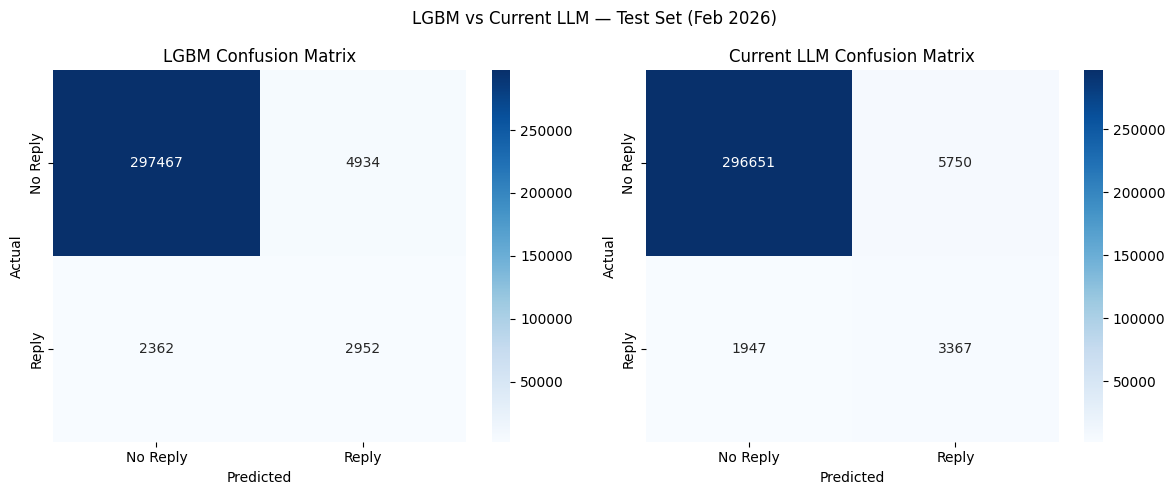


--- Summary ---
Current LLM outperforms LGBM: F1 score is 1.94% higher.


In [64]:
# LGBM vs Current LLM: Comparison on Test Set (Feb 2026)
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns

# Baseline: current fine-tuned LLM predictions (on test set)
y_llm_pred = test_df["current_system_predicted_reply"].astype(int)

# LGBM predictions (already computed: y_test_pred)
# y_test = ground truth

print("=" * 60)
print("LGBM vs Current LLM — Test Set Comparison")
print("=" * 60)

# Metrics comparison table
metrics = ["Precision", "Recall", "F1"]
lgbm_vals = [
    precision_score(y_test, y_test_pred, zero_division=0),
    recall_score(y_test, y_test_pred, zero_division=0),
    f1_score(y_test, y_test_pred, zero_division=0),
]
llm_vals = [
    precision_score(y_test, y_llm_pred, zero_division=0),
    recall_score(y_test, y_llm_pred, zero_division=0),
    f1_score(y_test, y_llm_pred, zero_division=0),
]
diff = [a - b for a, b in zip(lgbm_vals, llm_vals)]

comp_df = pd.DataFrame({
    "Metric": metrics,
    "LGBM": [f"{v:.4f}" for v in lgbm_vals],
    "Current LLM": [f"{v:.4f}" for v in llm_vals],
    "Difference (LGBM - LLM)": [f"{d:+.4f}" for d in diff],
})
print("\nMetrics:")
print(comp_df.to_string(index=False))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lgbm = confusion_matrix(y_test, y_test_pred)
cm_llm = confusion_matrix(y_test, y_llm_pred)

sns.heatmap(cm_lgbm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Reply", "Reply"], yticklabels=["No Reply", "Reply"])
axes[0].set_title("LGBM Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

sns.heatmap(cm_llm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["No Reply", "Reply"], yticklabels=["No Reply", "Reply"])
axes[1].set_title("Current LLM Confusion Matrix")
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

plt.suptitle("LGBM vs Current LLM — Test Set (Feb 2026)", fontsize=12)
plt.tight_layout()
plt.show()

# Summary for non-technical stakeholders
f1_diff = f1_score(y_test, y_test_pred, zero_division=0) - f1_score(y_test, y_llm_pred, zero_division=0)
print("\n--- Summary ---")
if f1_diff > 0:
    print(f"LGBM outperforms the current LLM: F1 score is {f1_diff:.2%} higher.")
elif f1_diff < 0:
    print(f"Current LLM outperforms LGBM: F1 score is {-f1_diff:.2%} higher.")
else:
    print("Both models perform similarly on F1 score.")


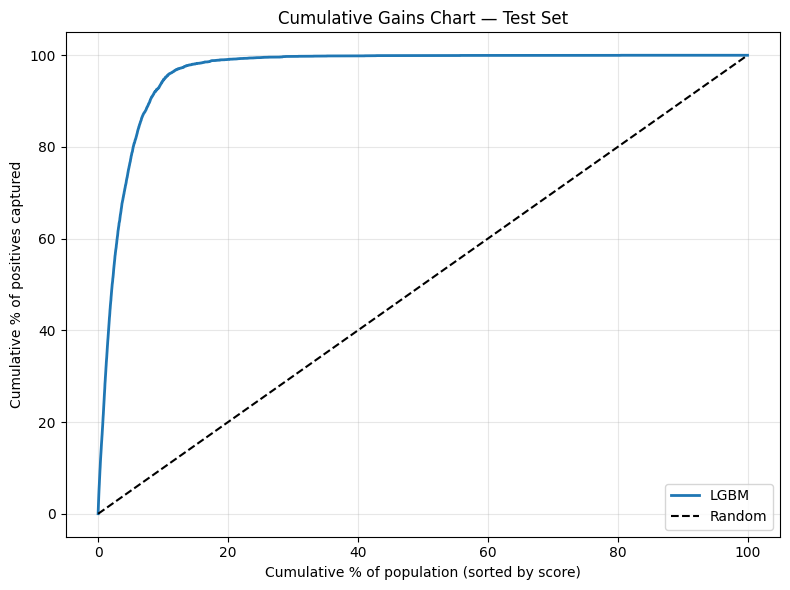

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create dataframe with predictions and actuals
lift_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_proba": y_test_proba,
})
lift_df = lift_df.sort_values("y_proba", ascending=False).reset_index(drop=True)

# Add deciles (1 = top 10% by score, 10 = bottom 10%)
n = len(lift_df)
lift_df["decile"] = pd.qcut(lift_df.index, q=10, labels=range(1, 11), duplicates="drop")

# Cumulative % of population (x) and cumulative % of positives captured (y)
lift_df["cum_pct_pop"] = np.arange(1, len(lift_df) + 1) / len(lift_df) * 100
lift_df["cum_positives"] = lift_df["y_true"].cumsum()
lift_df["cum_pct_positives"] = lift_df["cum_positives"] / lift_df["y_true"].sum() * 100

plt.figure(figsize=(8, 6))
plt.plot(lift_df["cum_pct_pop"], lift_df["cum_pct_positives"], label="LGBM", linewidth=2)
plt.plot([0, 100], [0, 100], "k--", label="Random")
plt.xlabel("Cumulative % of population (sorted by score)")
plt.ylabel("Cumulative % of positives captured")
plt.title("Cumulative Gains Chart — Test Set")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**What it shows:** Imagine we sort all emails by how likely the model thinks each one needs a reply (highest scores first). The chart answers: *"If we focus on the top X% of emails the model flags, what fraction of all *actual* replies do we capture?"*

**How to read it:**
- **X-axis:** Cumulative % of emails we look at (starting from those the model rates highest).
- **Y-axis:** Cumulative % of all true reply-worthy emails found so far.
- **Diagonal gray line (random):** If we picked emails at random, we’d find positives at the same rate as in the full set. The diagonal shows that “random” baseline.
- **Curve above the diagonal:** Our model does better than random. The higher and more bowed the curve, the more we’re concentrating replies in the top portion we look at.

**Example:** If the curve reaches 80% on the y-axis when x = 20%, it means by reviewing only the top 20% of emails (by model score), we capture 80% of all emails that actually needed a reply. That’s a strong improvement over random, which would only give us 20% of replies in the top 20%.

---

## Section 5 — Recommendation

Based on your analysis: **should Fyxer replace the LLM with a traditional ML approach?**

This is not a trick question — there is no single right answer. We want to see you reason about tradeoffs.

> Recommendation: We should pursue a hybrid approach rather than replacing the LLM with a traditional ML model. The analysis shows that the traditional ML model improves precision but reduces recall compared to the LLM. A hybrid lets us use each model where it performs best.
>
> Proposed rule: For each email, run the traditional ML model first. If the predicted probability of reply exceeds a tuned threshold X (e.g., 0.6–0.7, validated on a holdout set), use the ML prediction; otherwise, fall back to the LLM. The threshold should be chosen so that ML predictions in this high-confidence band outperform the LLM on precision without degrading recall too much when combined with the LLM fallback.
>
> Operational benefits: This design reduces LLM usage for clear cases, lowering cost and latency, while the LLM continues to handle ambiguous and cold-start cases. Cold-start users and new senders should route to the LLM by default.

---

## Section 6 — Deployment

Assume your model is good enough to ship. How would you get it from this notebook into production?

Think about:
- **Cold start:** How do you handle new users who have no history?
- **Monitoring:** How would you know if the model is working well — or failing silently?
- **Retraining:** How and when would you retrain?

### Production Considerations

1. **Export the model:** Serialize the trained LGBM (e.g., `lgb_final`) with `joblib` or LightGBM's native `save_model()`.
2. **Feature pipeline:** Replicate the data prep (bool→int, `subject_prefix` encoding, null handling) in a shared module or service used by both training and inference.
3. **Inference service:** Expose the model via an API (e.g., FastAPI, Flask) or integrate into existing backend; load model at startup.
4. **Threshold:** Store the optimal threshold (e.g., `best_threshold`) in config; use it at inference to convert probabilities to binary predictions.

---

### Cold Start

- **New users** (no email history): Sender- and user-level features are null or uninformative. **Fallback to the LLM** for these users until sufficient data exists (e.g., 30+ days of activity, N emails received).
- **New senders** (first email from a sender): `reply_rate_sender_alltime`, `days_since_last_email_from_sender` are null. The model can still use user-level and email-level features; predictions may be noisier. Consider routing to LLM for first contact, or using ML with a lower confidence threshold for these cases.
- **Implementation:** Add a pre-check: if `user_tenure_days < 30` or sender has `< 2` prior emails, route to LLM. Otherwise, use the traditional ML model.

---

### Monitoring

- **Performance metrics:** Track precision, recall, F1 (or business KPIs) on a sample of predictions vs. actual replies, computed daily or weekly. Alert if metrics drop below a baseline (e.g., −5% vs. last month).
- **Distribution drift:** Monitor feature distributions (e.g., `reply_rate_sender_alltime`, `subject_length`) and label rate; alert on significant shifts that could degrade the model.
- **Prediction distribution:** Track the share of emails with score > threshold, and the mean predicted probability. Sudden changes may indicate drift or model issues.
- **Latency & availability:** Log inference latency and error rates; alert on P99 latency or error-rate spikes.

---

### Retraining

- **Schedule:** Retrain monthly or quarterly, using a rolling window (e.g., last 6–12 months) to balance recency with stability.
- **Trigger:** Retrain sooner if monitoring detects performance decay or significant distribution shift.
- **Process:** Re-run the training pipeline (prep → tune → train) on fresh data; validate on holdout; A/B test new model vs. current before full rollout.


---

## Section 7 — Day One

If this were your day-one problem at Fyxer, what would you do differently from what you've done here? What questions would you ask the team?

This is intentionally open-ended.

> I’d pursue three coordinated steps:
>
> 1. Low-hanging fruit (traditional ML): Run an experiment on real production data to validate that the approach works outside the synthetic dataset. A/B test against the current LLM and measure precision, recall, and cost.
>
> 2. DNN with text: Train a DNN that uses subject and body text (e.g., embeddings) together with the existing tabular features. This captures semantics and can help when behavioral features are sparse.
>
> 3. Hybrid cascade: Use ML as the first tier. If the ML score is below threshold X₁, route to the DNN. If the DNN score is below X₂, fall back to the fine-tuned LLM. Tune X₁ and X₂ on a validation set; calibrate ML and DNN outputs if needed. Cold-start users and senders should skip ML.
>
> Rollout: Ship the ML tier first; once validated, add the DNN, then integrate the full cascade. Track tier usage, per-tier accuracy, and cost/latency savings. The goal is to shift traffic toward in-house models over time while reducing LLM calls and cost.